In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import time


# Get project root path (parent of /notebooks)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.pricing_models.black_scholes import (
    BlackScholesModel,
    price_option as price_bsm
)

from src.pricing_models.binomial_tree import (
    BinomialTreeModel,
    price_binomial
)

from src.pricing_models.convergence import (
    select_convergence_snapshots,
    analyze_convergence_for_snapshot,
    run_full_convergence_analysis,
    generate_convergence_plots
)

print("Modules imported successfully.")


Modules imported successfully.


In [2]:
# Cell 2 - Load configuration
with open('../config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded.")
print(f"Project Name: {config['project']['name']}")
print(f"Team: {config['project']['team']}")


Configuration loaded.
Project Name: HDFCBANK Options Analysis
Team: Strike Squad


In [3]:
# Cell 3 - Parameters used for validating the pricing models
test_params = {
    'stock_price': 1650.0,
    'strike_price': 1650.0,
    'time_to_expiry': 30/365,
    'risk_free_rate': 0.067,
    'volatility': 0.25,
    'dividend_yield': 0.0
}

for key, value in test_params.items():
    print(f"{key}: {value}")


stock_price: 1650.0
strike_price: 1650.0
time_to_expiry: 0.0821917808219178
risk_free_rate: 0.067
volatility: 0.25
dividend_yield: 0.0


In [4]:
# Cell 4 - Validate Black-Scholes-Merton implementation
bsm = BlackScholesModel()

call_price_bsm = bsm.price_call(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    test_params['dividend_yield']
)

put_price_bsm = bsm.price_put(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    test_params['dividend_yield']
)

print(f"BSM Call Price: ₹{call_price_bsm:.2f}")
print(f"BSM Put Price:  ₹{put_price_bsm:.2f}")


BSM Call Price: ₹51.71
BSM Put Price:  ₹42.65


In [5]:
# Cell 5 - Compute Greeks
delta_call = bsm.calculate_delta(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    'call',
    test_params['dividend_yield']
)

gamma = bsm.calculate_gamma(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    test_params['dividend_yield']
)

vega = bsm.calculate_vega(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    test_params['dividend_yield']
)

print(f"Delta (Call): {delta_call:.4f}")
print(f"Gamma:        {gamma:.6f}")
print(f"Vega:         {vega:.2f} (per 1% vol change)")

# Verify put-call parity
parity = bsm.verify_put_call_parity(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    test_params['dividend_yield']
)

print("\nPut-Call Parity Check:")
for key, val in parity.items():
    print(f"{key}: {val}")


Delta (Call): 0.5449
Gamma:        0.003352
Vega:         1.88 (per 1% vol change)

Put-Call Parity Check:
call_price: 51.70870949402979
put_price: 42.647380709288086
left_side: 9.061328784741704
right_side: 9.06132878474159
difference: 1.1368683772161603e-13
parity_holds: True


In [6]:
# Cell 6 - Validate binomial pricing at a fixed step count
n_steps_test = 50

call_price_binom = price_binomial(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    n_steps_test,
    'call',
    'european',
    test_params['dividend_yield']
)

put_price_binom = price_binomial(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    n_steps_test,
    'put',
    'european',
    test_params['dividend_yield']
)

print(f"Binomial Call Price (n={n_steps_test}): ₹{call_price_binom:.2f}")
print(f"Binomial Put Price  (n={n_steps_test}): ₹{put_price_binom:.2f}")


Binomial Call Price (n=50): ₹51.47
Binomial Put Price  (n=50): ₹42.41


In [7]:
# Cell 7 - Compare binomial prices against BSM across different step counts
steps_list = config['pricing']['binomial_steps_list']

from src.pricing_models.binomial_tree import price_binomial
from src.pricing_models.black_scholes import BlackScholesModel

bsm = BlackScholesModel()

# Compute BSM benchmark price
bsm_price = bsm.price_call(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    test_params['dividend_yield']
)

bin_prices = []
abs_errors = []
pct_errors = []
run_times = []

for n in steps_list:
    start_time = time.time()

    price_n = price_binomial(
    test_params['stock_price'],
    test_params['strike_price'],
    test_params['time_to_expiry'],
    test_params['risk_free_rate'],
    test_params['volatility'],
    n,
    'call',
    'european',
    test_params['dividend_yield']
)


    end_time = time.time()

    bin_prices.append(price_n)
    abs_errors.append(abs(price_n - bsm_price))
    pct_errors.append(abs(price_n - bsm_price) / bsm_price * 100)
    run_times.append(end_time - start_time)

convergence = {
    "steps": steps_list,
    "binomial_price": bin_prices,
    "computation_time": run_times
}

conv_df = pd.DataFrame({
    'Steps': convergence['steps'],
    'Binomial_Price': convergence['binomial_price'],
    'BSM_Price': [call_price_bsm] * len(steps_list),
    'Absolute_Error': [abs(bp - call_price_bsm) for bp in convergence['binomial_price']],
    'Relative_Error_Pct': [
        abs(bp - call_price_bsm)/call_price_bsm * 100
        for bp in convergence['binomial_price']
    ],
    'Computation_Time': convergence['computation_time']
})

conv_df


,Steps,Binomial_Price,BSM_Price,Absolute_Error,Relative_Error_Pct,Computation_Time
0,10,50.545794,51.708709,1.162916,2.248975,0.000061
1,25,52.176726,51.708709,0.468016,0.905101,0.000215
2,50,51.473428,51.708709,0.235282,0.455014,0.000856
3,100,51.590916,51.708709,0.117794,0.227803,0.003535
4,200,51.649775,51.708709,0.058934,0.113974,0.012147


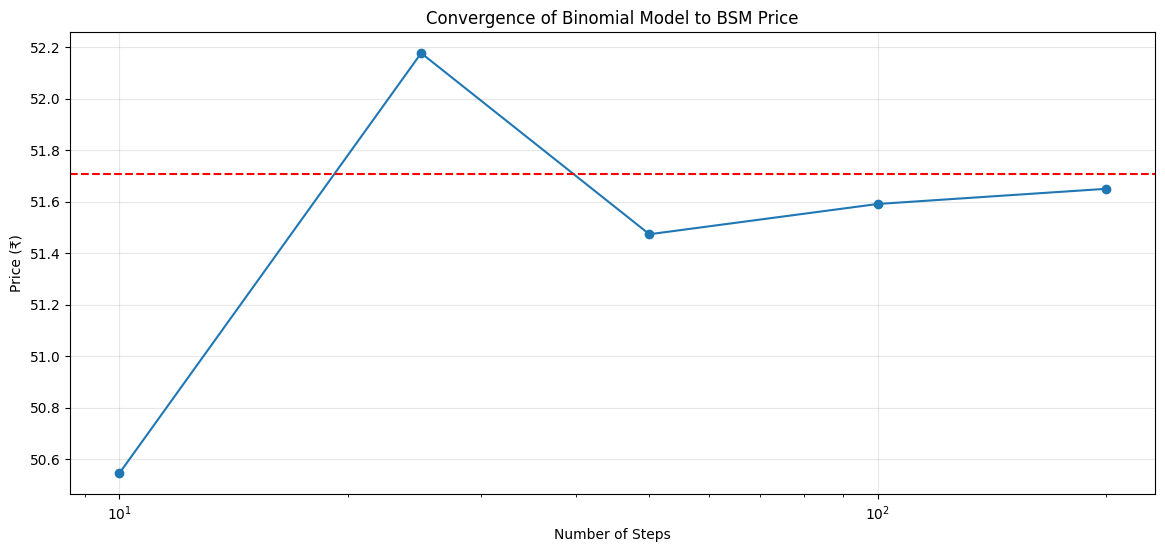

In [8]:
# Cell 8 - Convergence Plot

plt.figure(figsize=(14, 6))
plt.plot(conv_df['Steps'], conv_df['Binomial_Price'], marker='o')
plt.axhline(call_price_bsm, linestyle='--', color='red')

plt.xscale('log')
plt.xlabel("Number of Steps")
plt.ylabel("Price (₹)")
plt.title("Convergence of Binomial Model to BSM Price")
plt.grid(alpha=0.3)

plt.savefig('../slides/figures/convergence_analysis_0271.png', dpi=300)
plt.show()



In [9]:
# === RECOMPUTE & VALIDATE CONVERGENCE RESULTS (corrected for pricing_models) ===

import sys, os, traceback
from pathlib import Path

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root on sys.path:", project_root)

print("\nLooking for input files:")
candidates = {
    "atm_lookup": "../data/processed/atm_lookup_271P.csv",
    "stock": "../data/processed/hdfc_stock_processed_271P_enriched.csv",
    "dividends": "../data/processed/hdfc_dividends_271P.csv",
    "config": "../config/config.yaml",
}
for k, p in candidates.items():
    print(f"  {k:10s}: {p} -> {'FOUND' if Path(p).exists() else 'MISSING'}")

# Import convergence from correct package: src.pricing_models.convergence
try:
    import importlib
    conv_mod = importlib.import_module("src.pricing_models.convergence")
    importlib.reload(conv_mod)
    print("\nImported src.pricing_models.convergence successfully.")
except Exception:
    print("\nERROR importing convergence module:")
    traceback.print_exc()
    raise

# Load inputs
import pandas as pd
import yaml

atm_path = candidates["atm_lookup"]
stock_path = candidates["stock"]
div_path = candidates["dividends"]
cfg_path = candidates["config"]

atm = pd.read_csv(atm_path)
print(f"\nLoaded atm_lookup ({len(atm)} rows).")

stock = pd.read_csv(stock_path) if Path(stock_path).exists() else None
if stock is not None:
    print(f"Loaded stock file ({len(stock)} rows).")
else:
    print("Stock file missing — snapshot selection may fallback.")

dividends = pd.read_csv(div_path) if Path(div_path).exists() else pd.DataFrame()
if len(dividends) > 0:
    print(f"Loaded dividends file ({len(dividends)} rows).")
else:
    print("Dividends file missing — no dividend snapshot (fine).")

if Path(cfg_path).exists():
    with open(cfg_path, "r") as f:
        config = yaml.safe_load(f)
    print("Loaded config.yaml")
else:
    print("config.yaml missing — using defaults.")
    config = {
        "pricing": {
            "binomial_steps_list": [5, 10, 20, 40, 80, 160],
            "convergence_tolerance": 0.50
        }
    }

# Run convergence analysis
out_csv = "../data/processed/convergence_results_271P.csv"
out_fig_dir = "../slides/figures"

try:
    print("\nRunning full convergence analysis...")
    run_func = getattr(conv_mod, "run_full_convergence_analysis", None)
    if run_func is None:
        raise AttributeError("run_full_convergence_analysis not found in convergence module")

    results_df = run_func(
        stock if stock is not None else atm,
        atm,
        dividends,
        config,
        output_path=out_csv
    )

    print(f"Convergence analysis completed. Saved: {out_csv}")

except Exception:
    print("\nERROR during convergence analysis:")
    traceback.print_exc()
    raise

# Generate plots
if hasattr(conv_mod, "generate_convergence_plots"):
    try:
        conv_mod.generate_convergence_plots(results_df, output_dir=out_fig_dir)
        print("Convergence plots saved:", out_fig_dir)
    except Exception:
        print("Error generating convergence plots:")
        traceback.print_exc()

# Final verification
print("\nFinal check:")
if Path(out_csv).exists():
    dfc = pd.read_csv(out_csv)
    print("Convergence CSV found.")
    print("Rows:", len(dfc))
    print("Scenarios:", dfc["scenario"].unique() if "scenario" in dfc.columns else "N/A")
    print("\nSample:")
    print(dfc.head().to_string(index=False))
else:
    print("Convergence CSV NOT created.")


Selected snapshots: ['Ex-Dividend', 'Supplementary-95', 'Supplementary-190', 'Supplementary-286', 'Supplementary-381']
Saved convergence CSV to: ../data/processed/convergence_results_271P.csv
Ex-Dividend: no numeric absolute_error values (binomial probably missing).
Supplementary-95: no numeric absolute_error values (binomial probably missing).
Supplementary-190: no numeric absolute_error values (binomial probably missing).
Supplementary-286: no numeric absolute_error values (binomial probably missing).
Supplementary-381: no numeric absolute_error values (binomial probably missing).


Project root on sys.path: /Users/shubhra/hdfcbank-strike-squad

Looking for input files:
  atm_lookup: ../data/processed/atm_lookup_271P.csv -> FOUND
  stock     : ../data/processed/hdfc_stock_processed_271P_enriched.csv -> FOUND
  dividends : ../data/processed/hdfc_dividends_271P.csv -> FOUND
  config    : ../config/config.yaml -> FOUND

Imported src.pricing_models.convergence successfully.

Loaded atm_lookup (478 rows).
Loaded stock file (508 rows).
Loaded dividends file (3 rows).
Loaded config.yaml

Running full convergence analysis...
Convergence analysis completed. Saved: ../data/processed/convergence_results_271P.csv


Saved convergence price plot.
Failed to create error convergence plot: Data has no positive values, and therefore cannot be log-scaled.


Convergence plots saved: ../slides/figures

Final check:
Convergence CSV found.
Rows: 25
Scenarios: ['Ex-Dividend' 'Supplementary-95' 'Supplementary-190' 'Supplementary-286'
 'Supplementary-381']

Sample:
   scenario  n_steps  binomial_price  bsm_price  absolute_error  relative_error_pct  computation_time_sec trade_date  stock_price  strike  volatility  days_to_expiry
Ex-Dividend       10             NaN  24.185909             NaN                 NaN          9.059906e-06 2024-05-06   741.052063   740.0        0.25              31
Ex-Dividend       25             NaN  24.185909             NaN                 NaN          4.053116e-06 2024-05-06   741.052063   740.0        0.25              31
Ex-Dividend       50             NaN  24.185909             NaN                 NaN          2.145767e-06 2024-05-06   741.052063   740.0        0.25              31
Ex-Dividend      100             NaN  24.185909             NaN                 NaN          2.145767e-06 2024-05-06   741.052063  

ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1000x600 with 1 Axes>

In [10]:
# Cell 9 - Save Results
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

conv_df.to_csv(output_dir / 'convergence_test_results_0271.csv', index=False)

summary = pd.DataFrame([{
    'bsm_call_price': call_price_bsm,
    'bsm_put_price': put_price_bsm,
    'binomial_call_n50': call_price_binom,
    'binomial_put_n50': put_price_binom
}])

summary.to_csv(output_dir / 'pricing_summary_0271.csv', index=False)

print("Results saved to processed/ directory.")


Results saved to processed/ directory.


In [11]:
print("Pricing Models Validation Completed.")
print("All outputs generated successfully.")

Pricing Models Validation Completed.
All outputs generated successfully.


In [12]:
# === Universal PDF Export Cell (Jupyter, macOS, LaTeX-free, automatic install) ===
import os, sys, subprocess, importlib
from nbconvert import HTMLExporter

# ---- Step 1: Install Playwright if missing ----
def ensure_playwright():
    spec = importlib.util.find_spec("playwright")
    if spec is None:
        print("Playwright not found. Installing into this kernel environment...")
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "playwright", "nbconvert"], check=True)
        print("Installing Chromium browser (required for PDF generation)...")
        subprocess.run([sys.executable, "-m", "playwright", "install", "chromium"], check=True)
        print("Playwright + Chromium installed.")
    else:
        print("Playwright already installed.")

ensure_playwright()

# After install, import async API
from playwright.async_api import async_playwright

# ---- Step 2: Ask for notebook filename ----
notebook_name = input("Enter notebook name (e.g. 01_data_acquisition.ipynb): ").strip()
if not notebook_name:
    raise SystemExit("Notebook name required.")
if not os.path.exists(notebook_name):
    raise FileNotFoundError(f"Notebook not found: {notebook_name}")

html_name = notebook_name.replace(".ipynb", ".html")
pdf_name = notebook_name.replace(".ipynb", ".pdf")

# ---- Step 3: Export notebook → HTML ----
print(f"Exporting {notebook_name} → {html_name} ...")
html_exporter = HTMLExporter()
html_exporter.exclude_input = False
html_exporter.template_name = "classic"

body, resources = html_exporter.from_filename(notebook_name)
with open(html_name, "w", encoding="utf-8") as f:
    f.write(body)
print(f"HTML saved as {html_name}")

# ---- Step 4: Render HTML → PDF using Chromium headless ----
abs_html = os.path.abspath(html_name)
file_url = "file://" + abs_html
print("Rendering PDF using Chromium...")

async def _export_pdf():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        ctx = await browser.new_context()
        page = await ctx.new_page()
        await page.goto(file_url, wait_until="networkidle")
        await page.pdf(
            path=pdf_name,
            format="A4",
            print_background=True,
            margin={"top": "12mm", "bottom": "12mm", "left": "12mm", "right": "12mm"}
        )
        await browser.close()

await _export_pdf()

print(f"PDF successfully created: {pdf_name}")


Playwright already installed.


Enter notebook name (e.g. 01_data_acquisition.ipynb):  03_pricing_models.ipynb


Exporting 03_pricing_models.ipynb → 03_pricing_models.html ...
HTML saved as 03_pricing_models.html
Rendering PDF using Chromium...
PDF successfully created: 03_pricing_models.pdf
